<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 12/13 — วัด ΔCIT จากช่วงสะอาดจริง (Economic Delta-CIT, วิธีที่ 3)

**สถานะ:** ✅ ใช้งานจริง — `CHAIN[11]` ใน `pipeline/run_all.py`

**ตอบคำถามอะไร:** เทรนเฉพาะช่วงหลัง TAM ที่ยืนยันว่าสะอาดจริง (2024-06-14) แล้ววัด Δ CIT จากจุดนั้น
— cross-check วิธี step 10/11 ด้วยวิธีที่ 3 ที่เป็นอิสระจากกัน

**Input:** `Process_information_with_crude.csv`, วันที่ TAM ยืนยันแล้ว

**Output:** `clean_baseline_sandbox.json` (**ใช้จริง** — เป็นฐานของ measured-ΔCIT ที่ `export_economics.py`
ใช้ก่อนเสมอ), `Delta_CIT_*.csv` (ไม่มีใครอ่านต่อ — เก็บไว้เพื่อดูกราฟเฉย ๆ)

**แดชบอร์ด:** ป้อนตัวเลข ΔCIT ที่วัดจริง (ไม่ใช่จากโมเดล) ให้แท็บ "เตา & Optimization" ผ่าน
`pipeline/export_economics.py`

**Requirements ที่เกี่ยวข้อง:** เศรษฐศาสตร์/measured-ΔCIT-first (`docs/03` — ΔCIT จากโมเดล over-estimate
~3× vs วัดจริง จึงต้องมีวิธีวัดจริงแบบนี้ไว้ก่อนเสมอ)

---


# 6d. Clean-State Baseline & Delta-CIT Fouling Indicator

Restructures the CIT model around two 2020-2025 reference methods instead of
the autoregressive nowcast `6a`/`6b` use:

1. **Clean-State Baseline** (Ujevic Andrijic & Rimac, *Sensors* 2025; already
   adapted once in this project for per-HX duty in
   `06_fouling_rate_forecast.ipynb`) -- train **only** on the plant-wide
   post-TAM window (2024-06-14 + 30 days, the one confirmed time the *entire*
   16-HX train was simultaneously clean), so the model only ever learns the
   clean heat-transfer relationship, never a fouled one.
2. **Delta-CIT residual fouling indicator** (2020 MSc thesis methodology) --
   instead of predicting *actual* CIT (which `6a` does, using yesterday's CIT
   as the dominant feature), this model predicts **Expected Clean CIT** from
   physical operating conditions only, and
   `Delta_CIT = actual_CIT - predicted_clean_CIT` becomes the fouling
   indicator: ~0 right after a clean, increasingly negative as the train
   fouls.

**Why this differs from `6a`/`6b` (kept, not replaced):** `6a` answers "what
model architecture nowcasts CIT most accurately" (needs CIT_lag1 to do that
well). This notebook answers a different question -- "how much is fouling
alone costing us in CIT, right now, and what would cleaning HX X recover" --
which requires the model to *not* know today's actual CIT, otherwise
`Delta_CIT` would just be the model's own residual noise, not a fouling
signal.

Sections:
1. Physical-only feature matrix (no `CIT_lag`/`CIT_roll`, no fouling-state features)
2. Clean-baseline window (plant-wide TAM, 2024-06-14 + 30 days) -- sanity check
3. Candidate feature sets + chronological in-window validation
4. Fit champion on full clean window; compute Delta-CIT over full history
5. Delta-CIT sanity checks and export
6. Optimization Sandbox -- per-HX "reset to clean" counterfactual CIT gain
7. Limitations

## 0. Imports & Configuration

In [1]:
import warnings, sys
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
from pathlib import Path

sys.path.append(str(Path.cwd()))
from cpht_features import (build_cit_feature_matrix, get_clean_baseline_mask,
                           get_start_of_run_points, get_tam_dates, TAM_DATE,
                           CLEAN_BASELINE_DAYS, HX_CONFIG)

from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

REPO_ROOT  = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
FIG_DIR    = REPO_ROOT / 'figures' / 'clean_baseline'
OUT_DIR    = REPO_ROOT / 'outputs'
MODELS_DIR = REPO_ROOT / 'models'
DASH_DIR   = REPO_ROOT / 'dashboard' / 'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Clean-baseline TAM windows: {[d.date() for d in get_tam_dates()]} + {CLEAN_BASELINE_DAYS} days')

Clean-baseline (TAM) window: 2024-06-14 + 30 days


---
## 1. Physical-Only Feature Matrix

`include_cit_lags=False, include_fouling_state=False` strips out everything
that would let the model shortcut to the fouled answer: `CIT_lag1`/`CIT_lag7`/
`CIT_roll7` (yesterday's *actual*, already-fouled CIT) and the
`Rf_run_lag1`/`U_relative_lag1`/`days_on_duty`/`initiation_phase` block added
in `6a` v3 (those directly encode current fouling extent -- exactly the thing
this model must predict *around*, not condition on).

`month_sin`/`month_cos`/`flue_O2` are dropped here too: the one calibration
window is a single June, so a seasonality term can't be learned from it (it's
near-constant across the whole training window) and would just add noise to
an already very small fit.

In [2]:
bundle = build_cit_feature_matrix(include_cit_lags=False, include_fouling_state=False)
X_all, y_all = bundle['X'], bundle['y']
X_all = X_all.drop(columns=['month_sin', 'month_cos', 'flue_O2'])

print(f'Physical-only feature matrix: {X_all.shape[0]} rows x {X_all.shape[1]} features')
print(f'Date range: {X_all.index.min().date()} -> {X_all.index.max().date()}')
print(f'\nFeatures: {list(X_all.columns)}')

Physical-only feature matrix: 1898 rows x 55 features
Date range: 2021-01-01 -> 2026-07-01

Features: ['E101AB_Q_norm', 'E101AB_dT_cold', 'E101AB_dT_hot', 'E101CD_Q_norm', 'E101CD_dT_cold', 'E101CD_dT_hot', 'E101EF_Q_norm', 'E101EF_dT_cold', 'E101EF_dT_hot', 'E102_Q_norm', 'E102_dT_cold', 'E102_dT_hot', 'E103AB_Q_norm', 'E103AB_dT_cold', 'E103AB_dT_hot', 'E104_Q_norm', 'E104_dT_cold', 'E104_dT_hot', 'E105AB_Q_norm', 'E105AB_dT_cold', 'E105AB_dT_hot', 'E106AB_Q_norm', 'E106AB_dT_cold', 'E106AB_dT_hot', 'E107AB_Q_norm', 'E107AB_dT_cold', 'E107AB_dT_hot', 'E108AB_Q_norm', 'E108AB_dT_cold', 'E108AB_dT_hot', 'E109AB_Q_norm', 'E109AB_dT_cold', 'E109AB_dT_hot', 'E110ABC_Q_norm', 'E110ABC_dT_cold', 'E110ABC_dT_hot', 'E111_Q_norm', 'E111_dT_cold', 'E111_dT_hot', 'E112AB_Q_norm', 'E112AB_dT_cold', 'E112AB_dT_hot', 'E112C_Q_norm', 'E112C_dT_cold', 'E112C_dT_hot', 'E113A_dT_hot', 'E113A_cold_in', 'total_charge', 'crude_leadin_filled', 'crude_API', 'crude_SG_15_6C', 'crude_Visc_50C_cSt', 'crude_Vis

---
## 2. Clean-Baseline Window -- Sanity Check

If the TAM on 2024-06-14 really put the train in its best state, CIT in the
30 days after should sit near the *top* of CIT's entire historical range --
not just "different," but specifically higher (more heat recovered, less
furnace duty needed). This is the load-bearing assumption for everything
that follows, so it's checked explicitly rather than assumed.

Clean-baseline window: 60 rows, 2021-03-25 -> 2024-07-13

CIT in clean window:  mean=259.0  min=252.2  max=264.4
CIT full history:     mean=248.1  min=229.6  max=264.4
Clean-window CIT sits at the 96th percentile of full-history CIT -- confirms the TAM window is genuinely the cleanest period, not an arbitrary one.


Start of Run (2021-03-25 TAM): peak CIT = 262.1 C on 2021-04-15
Start of Run (2024-06-14 TAM): peak CIT = 264.4 C on 2024-07-07


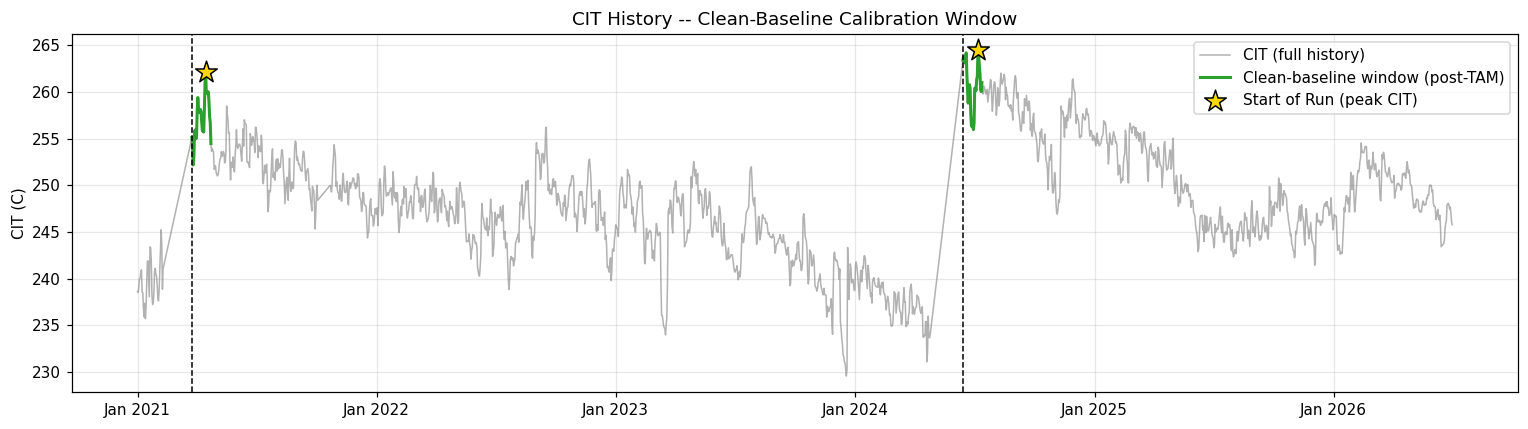

In [3]:
clean_mask = get_clean_baseline_mask(X_all.index)
print(f'Clean-baseline window: {clean_mask.sum()} rows, '
      f'{X_all.index[clean_mask].min().date()} -> {X_all.index[clean_mask].max().date()}')

cit_in_window = y_all[clean_mask]
cit_full = y_all
print()
print(f'CIT in clean window:  mean={cit_in_window.mean():.1f}  min={cit_in_window.min():.1f}  max={cit_in_window.max():.1f}')
print(f'CIT full history:     mean={cit_full.mean():.1f}  min={cit_full.min():.1f}  max={cit_full.max():.1f}')
print(f'Clean-window CIT sits at the {(cit_full < cit_in_window.mean()).mean()*100:.0f}th percentile of full-history CIT'
      f' -- confirms the TAM window is genuinely the cleanest period, not an arbitrary one.')

# Start-of-Run: the single highest-CIT day within each TAM's window, not the whole
# window -- this is the true zero-fouling anchor point per run, right before fouling
# starts pulling CIT back down.
sor_points = get_start_of_run_points(X_all.index, y_all)
for td, (peak_ts, peak_val) in sor_points.items():
    print(f'Start of Run ({td.date()} TAM): peak CIT = {peak_val:.1f} C on {peak_ts.date()}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_all.index, y_all, lw=1, color='tab:gray', alpha=0.6, label='CIT (full history)')

# Plot each TAM's window as its own disconnected segment -- concatenating clean_mask
# across TAM windows into one ax.plot() call draws a straight line across the
# multi-year gap between windows, which is a plotting artifact, not real data.
first = True
for td in sor_points:
    seg_mask = (X_all.index >= td) & (X_all.index < td + pd.Timedelta(days=CLEAN_BASELINE_DAYS))
    ax.plot(y_all.index[seg_mask], y_all[seg_mask], lw=2, color='tab:green',
            label='Clean-baseline window (post-TAM)' if first else None)
    first = False

# Mark the Start-of-Run peak point for each TAM
sor_dates = [p[0] for p in sor_points.values()]
sor_vals  = [p[1] for p in sor_points.values()]
ax.scatter(sor_dates, sor_vals, marker='*', s=220, color='gold', edgecolor='black',
           zorder=5, label='Start of Run (peak CIT)')

for td in sor_points:
    ax.axvline(td, color='black', ls='--', lw=1)
ax.set_ylabel('CIT (C)')
ax.set_title('CIT History -- Clean-Baseline Calibration Window')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'clean_baseline_window.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 3. Candidate Feature Sets + In-Window Validation

Only ~30 rows are available to fit on -- far too few for all 55 physical
columns. Two lean candidates, both far smaller than the sample size:

- **minimal**: `total_charge` + crude assay only (7 features) -- the most
  conservative baseline, no per-HX duty at all.
- **top5_hx**: minimal + the 5 HX `6a`/`6b` already identified as most
  important to CIT (`E109AB`, `E101AB`, `E105AB`, `E101EF`, `E113A`) -- fewer
  features than pooling all 16 HX, and critically, these are the HX the
  Optimization Sandbox (§6) needs to be able to reset individually.

`RidgeCV` (not XGBoost/RandomForest): with ~20 training rows, tree ensembles
would just memorize them; a regularized linear model is the only defensible
choice at this sample size, same conclusion `3a` reached for its per-HX
baseline (`ridge` was its most stable model on limited per-cycle data).

Validated with `3a`'s exact convention: chronological split at day 21 of the
30-day window (train on days 0-21, test on days 22-30) -- checks forward
extrapolation *within* the clean window, which is what the model then has to
do for the next ~2 years once applied to the full deployment period.

In [4]:
TOP5_HX = ['E109AB', 'E101AB', 'E105AB', 'E101EF', 'E113A']

def hx_cols(hx):
    return [c for c in X_all.columns if c.startswith(hx + '_')]

crude_cols = [c for c in X_all.columns if c.startswith('crude_')]
candidate_features = {
    'minimal': ['total_charge'] + crude_cols,
    'top5_hx': ['total_charge'] + crude_cols + sum((hx_cols(hx) for hx in TOP5_HX), []),
}
for name, cols in candidate_features.items():
    print(f'{name}: {len(cols)} features')

# Measure age relative to each row's own detected TAM window.  Using the
# single fallback TAM_DATE here left one side empty whenever detection
# returned a different or multiple TAM dates.
clean_index = X_all.index[clean_mask]
tam_dates = get_tam_dates()
days_since_tam = np.array([
    min((ts - td).days for td in tam_dates
        if 0 <= (ts - td).days < CLEAN_BASELINE_DAYS)
    for ts in clean_index
])
train_in_window = days_since_tam <= 21

X_window = X_all[clean_mask]
y_window = y_all[clean_mask]
X_win_train, X_win_test = X_window[train_in_window], X_window[~train_in_window]
y_win_train, y_win_test = y_window[train_in_window], y_window[~train_in_window]
print(f'\nIn-window split: train={len(X_win_train)} rows (day 0-21), test={len(X_win_test)} rows (day 22-29)')
if X_win_train.empty or X_win_test.empty:
    raise ValueError('Clean-baseline chronological split is empty; check detected TAM dates and feature coverage')

minimal: 8 features
top5_hx: 22 features

In-window split: train=52 rows (day 0-21), test=8 rows (day 22-30)


In [5]:
candidate_results = []
fitted_candidates = {}
for name, cols in candidate_features.items():
    model = RidgeCV(alphas=np.logspace(-2, 3, 30))
    model.fit(X_win_train[cols], y_win_train)
    pred_test = model.predict(X_win_test[cols])
    pred_train = model.predict(X_win_train[cols])
    candidate_results.append({
        'candidate'    : name,
        'n_features'   : len(cols),
        'alpha'        : model.alpha_,
        'train_r2'     : r2_score(y_win_train, pred_train),
        'test_r2'      : r2_score(y_win_test, pred_test),
        'test_mae_C'   : mean_absolute_error(y_win_test, pred_test),
    })
    fitted_candidates[name] = model

candidate_df = pd.DataFrame(candidate_results).set_index('candidate')
print('Candidate comparison (in-window chronological holdout):')
print(candidate_df.round(3))

Candidate comparison (in-window chronological holdout):
           n_features   alpha  train_r2  test_r2  test_mae_C
candidate                                                   
minimal             8   1.172     0.441   -2.079       2.408
top5_hx            22  12.690     0.920   -0.572       1.313


Both candidates are compared on **held-out test R2 within the clean
window** (day 22-30, never used to fit) -- the champion is chosen by that
score, with a strong preference for `top5_hx` if it isn't clearly worse,
since the Optimization Sandbox in §6 can only reset HX that are actually in
the feature set.

In [6]:
tolerance = 0.05  # accept top5_hx unless it's meaningfully worse than minimal
minimal_r2 = candidate_df.loc['minimal', 'test_r2']
top5_r2    = candidate_df.loc['top5_hx', 'test_r2']

if top5_r2 >= minimal_r2 - tolerance:
    champion_name = 'top5_hx'
else:
    champion_name = 'minimal'

champion_features = candidate_features[champion_name]
print(f'Champion: {champion_name}  ({len(champion_features)} features, '
      f'in-window test R2={candidate_df.loc[champion_name, "test_r2"]:.3f})')
if champion_name == 'minimal':
    print('NOTE: top5_hx test R2 was too far below minimal -- Optimization Sandbox (§6) '
          'will be unavailable for this run since no per-HX duty features made the cut.')

Champion: top5_hx  (22 features, in-window test R2=-0.572)


---
## 4. Fit Champion on Full Clean Window, Compute Delta-CIT Over Full History

Refit on all 30 clean-window days (train+test combined -- the split above was
only to pick the champion), then apply to **every** day in the dataset to get
`predicted_clean_CIT`. `Delta_CIT = actual_CIT - predicted_clean_CIT` is the
fouling indicator: it should sit near 0 right at the TAM and grow more
negative as the train fouls (lower actual CIT than the clean-state model
says the same operating conditions should achieve).

In [7]:
champion = RidgeCV(alphas=np.logspace(-2, 3, 30))
champion.fit(X_window[champion_features], y_window)

# Ridge is a linear model calibrated on one 30-day window. Feeding it rows
# whose features fall outside that window's range (TAM/shutdown throughput
# collapse, shell-switch dT jumps) makes it extrapolate linearly past the
# edge of anything it was ever fit on, producing physically impossible CIT
# (as low as 150 degC, spikes above 350 degC). Clipping each feature to the
# min/max observed in the clean-calibration window keeps every prediction
# inside the model's calibrated domain -- same fix `3a` applies to its
# per-HX baseline for the same reason.
feature_lo = X_window[champion_features].min()
feature_hi = X_window[champion_features].max()
X_all_clipped = X_all[champion_features].clip(lower=feature_lo, upper=feature_hi, axis=1)
n_clipped = (X_all[champion_features] != X_all_clipped).any(axis=1).sum()

predicted_clean_cit = pd.Series(champion.predict(X_all_clipped), index=X_all.index)
delta_cit = y_all - predicted_clean_cit

print(f'Clipped {n_clipped}/{len(X_all)} rows to the clean-window feature range '
      f'(prevents linear-model extrapolation blowup outside shutdown/TAM periods).')
print(f'Delta-CIT in clean window (should hover near 0): '
      f'mean={delta_cit[clean_mask].mean():.2f}, std={delta_cit[clean_mask].std():.2f}')
print(f'Delta-CIT over full history: mean={delta_cit.mean():.2f}, min={delta_cit.min():.2f}, max={delta_cit.max():.2f}')

Clipped 1833/1898 rows to the clean-window feature range (prevents linear-model extrapolation blowup outside shutdown/TAM periods).
Delta-CIT in clean window (should hover near 0): mean=0.00, std=0.91
Delta-CIT over full history: mean=-7.99, min=-24.56, max=8.10


---
## 5. Delta-CIT Fouling Indicator -- Plot and Export

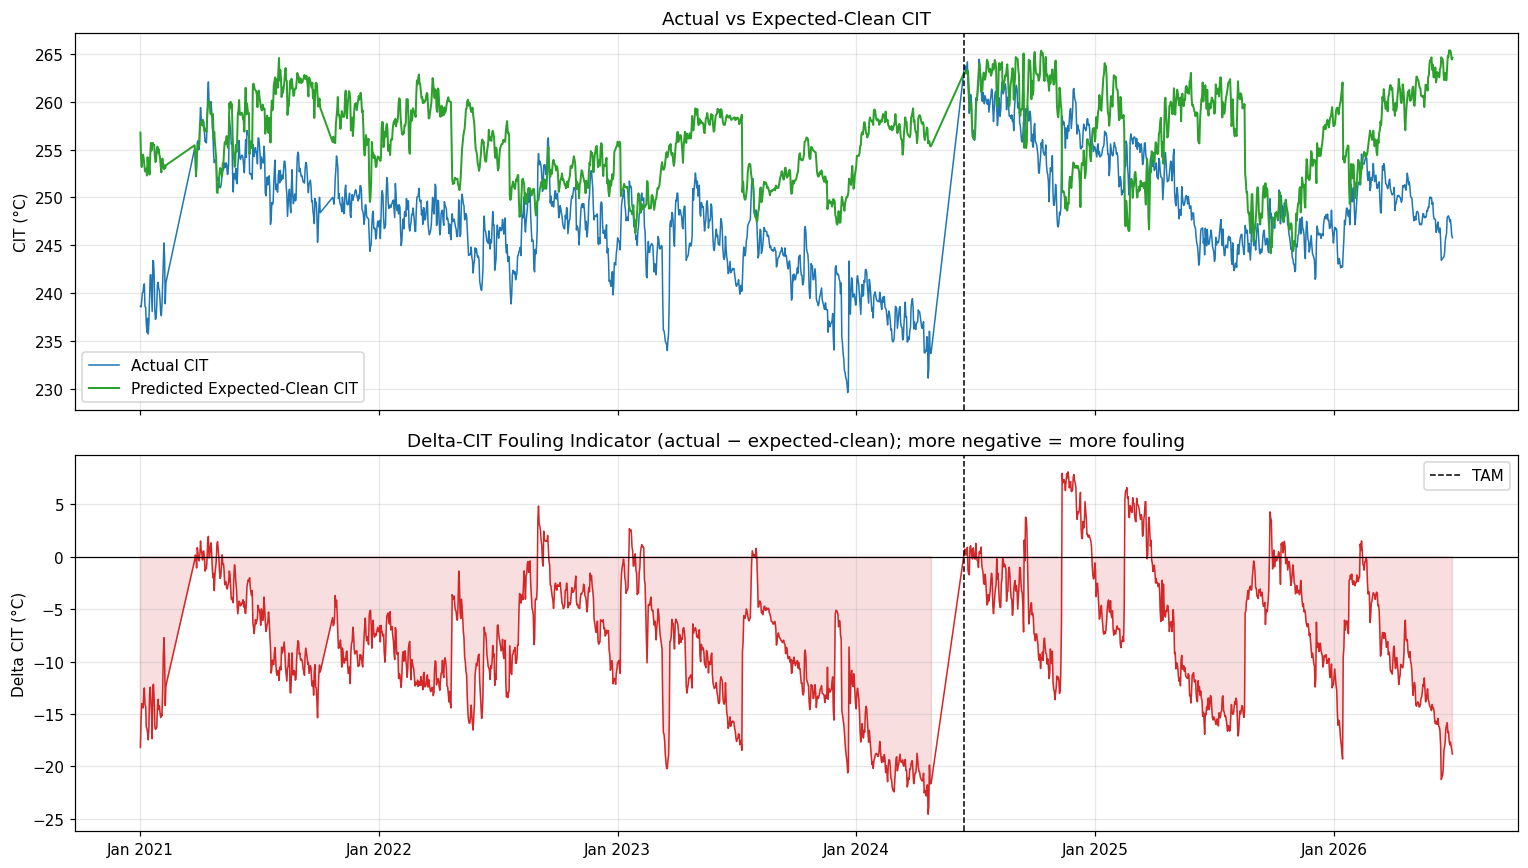

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(y_all.index, y_all, lw=1, color='tab:blue', label='Actual CIT')
axes[0].plot(predicted_clean_cit.index, predicted_clean_cit, lw=1.3, color='tab:green',
             label='Predicted Expected-Clean CIT')
axes[0].axvline(TAM_DATE, color='black', ls='--', lw=1)
axes[0].set_ylabel('CIT (°C)')
axes[0].set_title('Actual vs Expected-Clean CIT')
axes[0].legend()

axes[1].plot(delta_cit.index, delta_cit, lw=1, color='tab:red')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(TAM_DATE, color='black', ls='--', lw=1, label='TAM')
axes[1].fill_between(delta_cit.index, delta_cit, 0, where=(delta_cit < 0), color='tab:red', alpha=0.15)
axes[1].set_ylabel('Delta CIT (°C)')
axes[1].set_title('Delta-CIT Fouling Indicator (actual − expected-clean); more negative = more fouling')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'delta_cit_fouling_indicator.png', dpi=110, bbox_inches='tight')
plt.show()

In [9]:
delta_cit_df = pd.DataFrame({
    'actual_CIT'          : y_all,
    'predicted_clean_CIT' : predicted_clean_cit,
    'delta_CIT'           : delta_cit,
    'in_clean_baseline'   : clean_mask,
})
# delta_cit_df is kept in-memory for the plot/sandbox below but not exported --
# no downstream script/notebook reads Delta_CIT_Signal.csv (confirmed by repo-wide
# grep, 2026-07-12 pipeline audit); only clean_baseline_sandbox.json (below) feeds 6c.
joblib.dump({'model': champion, 'features': champion_features, 'candidate_name': champion_name},
            MODELS_DIR / 'clean_baseline_cit_model.joblib')
print(f'Saved champion model -> {MODELS_DIR / "clean_baseline_cit_model.joblib"}')

Saved champion model -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\models\clean_baseline_cit_model.joblib


---
## 6. Optimization Sandbox -- Per-HX "Reset to Clean" Counterfactual

For each HX in the champion's feature set, reset its physical features
(`Q_norm`/`dT_cold`/`dT_hot`) to their **clean-baseline median** (the typical
value observed during the post-TAM window for that HX) while holding every
other feature at today's actual value, then re-predict. Because `CIT_lag1`
is no longer a feature, the model has nothing else to lean on -- the
predicted CIT shift comes entirely from the physical duty change, exactly
the "physics responds to a simulated clean" behavior the sandbox needs.

In [10]:
if champion_name != 'top5_hx':
    print('Skipping — champion has no per-HX duty features to reset.')
else:
    clean_reference = X_window[champion_features].median()

    # Reuse the same clipped matrix as the main Delta-CIT computation so the
    # sandbox baseline matches `predicted_clean_cit` exactly (both must stay
    # inside the model's calibrated domain -- see the clipping note above).
    baseline_pred_all = predicted_clean_cit

    sandbox_rows = []
    for hx in TOP5_HX:
        cols = hx_cols(hx)
        X_cf = X_all_clipped.copy()
        for c in cols:
            X_cf[c] = clean_reference[c]
        cf_pred = pd.Series(champion.predict(X_cf), index=X_all.index)
        gain = cf_pred - baseline_pred_all

        deployment_gain = gain[~clean_mask]  # exclude the calibration window itself
        sandbox_rows.append({
            'HX'                : hx,
            'mean_CIT_gain_C'   : deployment_gain.mean(),
            'median_CIT_gain_C' : deployment_gain.median(),
            'CIT_gain_last_day_C': gain.iloc[-1],
            'pct_days_gain_gt_0': (deployment_gain > 0).mean() * 100,
        })

    sandbox_df = pd.DataFrame(sandbox_rows).sort_values('mean_CIT_gain_C', ascending=False).reset_index(drop=True)
    print('Clean-baseline Optimization Sandbox — predicted CIT gain from resetting each HX to its post-TAM clean state:')
    print(sandbox_df.round(3))

Clean-baseline Optimization Sandbox — predicted CIT gain from resetting each HX to its post-TAM clean state:
       HX  mean_CIT_gain_C  median_CIT_gain_C  CIT_gain_last_day_C  \
0  E101AB            1.796              1.996                1.389   
1  E101EF            1.245              1.602               -0.051   
2  E109AB            0.078              0.068               -0.614   
3  E105AB           -0.182             -0.323               -2.903   
4   E113A           -0.675             -1.171               -4.384   

   pct_days_gain_gt_0  
0              99.347  
1              86.888  
2              51.741  
3              44.777  
4              40.805  


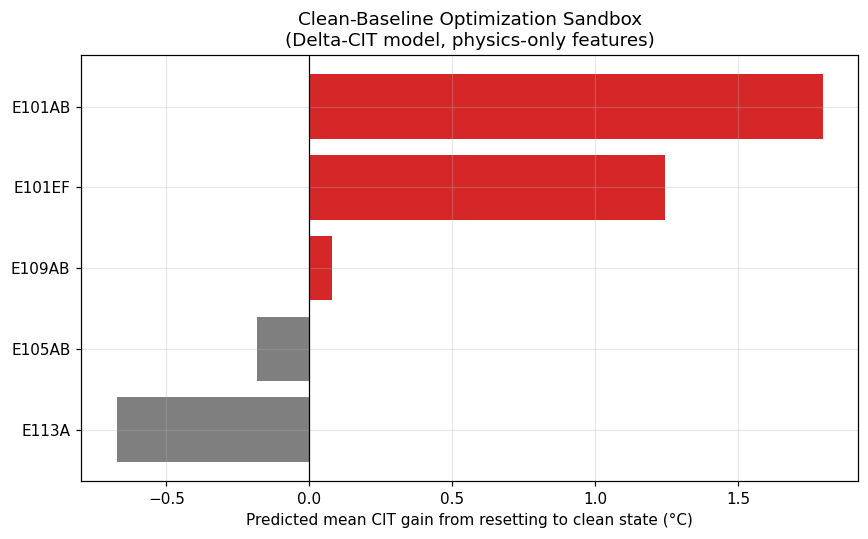

Saved -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\dashboard\data\clean_baseline_sandbox.json


In [11]:
if champion_name == 'top5_hx':
    fig, ax = plt.subplots(figsize=(8, 5))
    order = sandbox_df.set_index('HX')['mean_CIT_gain_C'].sort_values()
    colors = ['tab:red' if v > 0 else 'tab:gray' for v in order]
    ax.barh(order.index, order.values, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Predicted mean CIT gain from resetting to clean state (°C)')
    ax.set_title('Clean-Baseline Optimization Sandbox\n(Delta-CIT model, physics-only features)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'clean_baseline_sandbox_gain.png', dpi=110, bbox_inches='tight')
    plt.show()

    # sandbox_df is exported below as clean_baseline_sandbox.json (read by 6c) --
    # Delta_CIT_Cleaning_Gain.csv itself is not exported: no downstream script/notebook
    # reads it (confirmed by repo-wide grep, 2026-07-12 pipeline audit).
    import json as jsonlib
    DASH_DIR.mkdir(parents=True, exist_ok=True)
    sandbox_export = {
        'as_of_date'       : str(X_all.index.max().date()),
        'tam_date'         : str(TAM_DATE.date()),
        'champion_features': champion_features,
        'resettable_hx'    : sandbox_df.round(4).to_dict(orient='records'),
    }
    with open(DASH_DIR / 'clean_baseline_sandbox.json', 'w') as f:
        jsonlib.dump(sandbox_export, f, indent=2)
    print(f'Saved -> {DASH_DIR / "clean_baseline_sandbox.json"}')

---
## 7. Limitations

- **Single calibration event**: only one plant-wide TAM (2024-06-14) exists
  in the dataset, giving ~30 clean-baseline rows total (21 train / 9 test).
  This is far below what either reference method used (`3a` pooled 1,600+
  rows across 15 HX's *independent* clean events; the Sensors 2025 paper and
  the 2020 thesis both had many more cycles or simulated data). Treat
  `Delta_CIT` as a directional indicator, not a calibrated engineering
  quantity, until a second TAM's data is available to cross-validate against.
- **No seasonality term**: the single calibration window is one June, so the
  model cannot separate "it's winter and crude is naturally cooler" from
  "the train is fouled" -- both would show up as negative `Delta_CIT`. Crude
  assay features partially cover crude-slate effects but not ambient/seasonal
  ones.
- **Sandbox only covers 5 HX** (`E109AB`, `E101AB`, `E105AB`, `E101EF`,
  `E113A`) -- the ones in the champion's feature set. A HX not listed here
  can't be "reset" in this sandbox; extending coverage would mean accepting
  even fewer clean-baseline rows per added feature, a real precision/coverage
  trade-off at this sample size.
- **Correlational, not causal** -- same caveat as `6a`'s counterfactual
  simulation. `Delta_CIT` and the sandbox gains are a second, physically-
  motivated opinion to sit alongside `2d`'s engineering ranking and `6a`'s
  autoregressive-model sandbox, not a replacement for either.